DINOtool offers a high-level class, `DinoToolModel` for easier usage. This notebook demonstrates some of the features of this class.

Using model shortcut: dinov3-s -> facebook/dinov3-vits16-pretrain-lvd1689m
Using model: facebook/dinov3-vits16-pretrain-lvd1689m on device: cuda


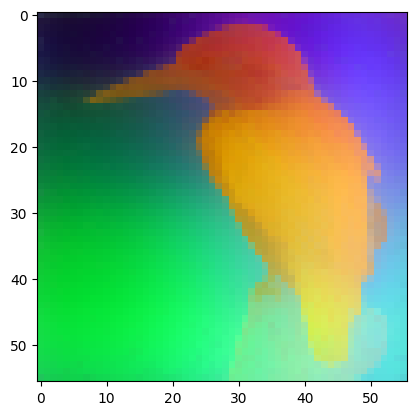

In [1]:
# Using the model can be as simple as this:
from dinotool import DinoToolModel
from PIL import Image
import matplotlib.pyplot as plt
model = DinoToolModel("dinov3-s")
img = Image.open("../test/data/bird1.jpg")

features = model(model.get_transform(img.size).transform(img).unsqueeze(0))
plt.imshow(model.pca(features))

# Additionally, you can specify device and verbosity:
```python
model = DinoToolModel(model_name="radio-b",
                      device="cuda", # by default uses cuda if available
                      verbose=True) # print model details. Default False
```

In [2]:
DinoToolModel.available_models() # Lists model shortcuts.

{'vit-s': 'dinov2_vits14_reg',
 'vit-b': 'dinov2_vitb14_reg',
 'vit-l': 'dinov2_vitl14_reg',
 'vit-g': 'dinov2_vitg14_reg',
 'dinov2-s': 'dinov2_vits14_reg',
 'dinov2-b': 'dinov2_vitb14_reg',
 'dinov2-l': 'dinov2_vitl14_reg',
 'dinov2-g': 'dinov2_vitg14_reg',
 'siglip1': 'hf-hub:timm/ViT-B-16-SigLIP-i18n-256',
 'siglip2': 'hf-hub:timm/ViT-B-16-SigLIP2-512',
 'siglip2-so400m-384': 'hf-hub:timm/ViT-SO400M-16-SigLIP2-384',
 'siglip2-so400m-512': 'hf-hub:timm/ViT-SO400M-16-SigLIP2-512',
 'siglip2-b16-256': 'hf-hub:timm/ViT-B-16-SigLIP2-256',
 'siglip2-b16-512': 'hf-hub:timm/ViT-B-16-SigLIP2-512',
 'siglip2-b32-256': 'hf-hub:timm/ViT-B-32-SigLIP2-256',
 'clip': 'hf-hub:timm/vit_base_patch16_clip_224.openai',
 'dinov3-s': 'facebook/dinov3-vits16-pretrain-lvd1689m',
 'dinov3-splus': 'facebook/dinov3-vits16plus-pretrain-lvd1689m',
 'dinov3-b': 'facebook/dinov3-vitb16-pretrain-lvd1689m',
 'dinov3-l': 'facebook/dinov3-vitl16-pretrain-lvd1689m',
 'dinov3-hplus': 'facebook/dinov3-vith16plus-pretra

Calculate features on an image using three backbones:

In [3]:
dinov3 = DinoToolModel(model_name="dinov3-s")
radio = DinoToolModel(model_name="radio-b")
siglip2 = DinoToolModel(model_name="siglip2")
dinov3

Using model shortcut: dinov3-s -> facebook/dinov3-vits16-pretrain-lvd1689m
Using model: facebook/dinov3-vits16-pretrain-lvd1689m on device: cuda
Using model shortcut: radio-b -> NVlabs/RADIO/c-radio_v3-b


Using cache found in /home/mikko/.cache/torch/hub/NVlabs_RADIO_main


Using model: NVlabs/RADIO/c-radio_v3-b on device: cuda


Using cache found in /home/mikko/.cache/torch/hub/NVlabs_RADIO_main


Using model shortcut: siglip2 -> hf-hub:timm/ViT-B-16-SigLIP2-512
Using model: hf-hub:timm/ViT-B-16-SigLIP2-512 on device: cuda


DinoToolModel(model_name='facebook/dinov3-vits16-pretrain-lvd1689m', device='cuda')

In [4]:
# get_transform returns the preprocessing transform specific to the model
tf_dinov3 = dinov3.get_transform(img.size)
tf_radio = radio.get_transform(img.size)
tf_siglip2 = siglip2.get_transform(img.size)
tf_dinov3

DINOTransform(transform=Compose(
    Resize(size=(896, 896), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), resize_size=(896, 896), feature_map_size=(56, 56))

In [5]:
import torch
# The transform wrappers have the property .transform that returns the actual transform
img_tensor_dinov3 = tf_dinov3.transform(img).unsqueeze(0)
img_tensor_radio = tf_radio.transform(img).unsqueeze(0)
img_tensor_siglip2 = tf_siglip2.transform(img).unsqueeze(0)

In [6]:
# Actual feature extraction can be done by calling the model instance
# The output is a LocalFeatures object that contains the features and necessary metadata
features_dinov3 = dinov3(img_tensor_dinov3)
features_radio = radio(img_tensor_radio)
features_siglip2 = siglip2(img_tensor_siglip2)

In [7]:
features_dinov3

LocalFeatures(full, normalized, shape=(1, 56, 56, 384))

In [8]:
# LocalFeatures can be converted to a flat representation and back
print(features_dinov3.flat().shape)
print(features_dinov3.full().shape)

torch.Size([1, 3136, 384])
torch.Size([1, 56, 56, 384])


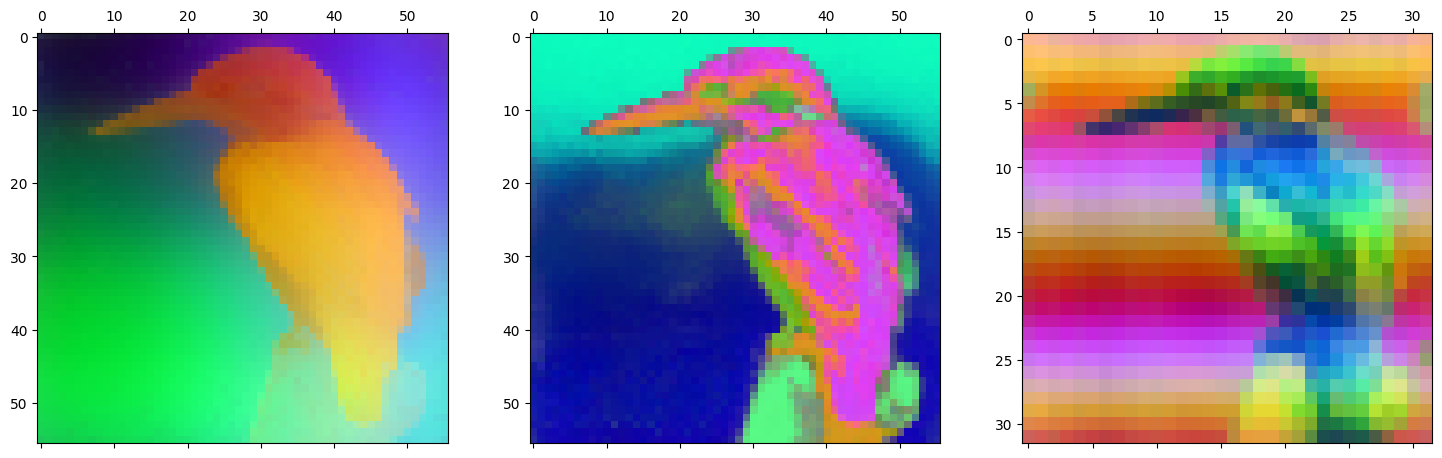

In [9]:
# the DinoToolModel instance can be also used to transform features into a PCA representation
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].matshow(dinov3.pca(features_dinov3))
ax[1].matshow(radio.pca(features_radio))
ax[2].matshow(siglip2.pca(features_siglip2))

In [10]:
# If you want both global and local features, you can get them by setting features="all"
local_dinov3, global_dinov3 = dinov3(img_tensor_dinov3, features="all")

In [11]:
local_dinov3

LocalFeatures(flat, normalized, shape=(1, 3136, 384))

In [12]:
print(type(global_dinov3))
print(global_dinov3.shape)

<class 'torch.Tensor'>
torch.Size([1, 384])


# Handling video

`dinotool` has classes for handling video and image folder datatypes. Batches from these can be passed to the `DinoToolModel`

In [13]:
import torch
from dinotool.data import Video, VideoDataset

video = Video("../test/data/sintel.mp4")

video_transform = dinov3.get_transform(video.resolution)
ds = VideoDataset(video, transform=video_transform.transform)
dataloader = torch.utils.data.DataLoader(ds, batch_size=4, shuffle=False)

In [14]:
batch = next(iter(dataloader))
features = dinov3(batch["img"])
features

LocalFeatures(full, normalized, shape=(4, 34, 80, 384))

In [15]:
# PCA is calculated over the first frame
pca_array = dinov3.pca(features)
pca_array.shape

(4, 34, 80, 3)

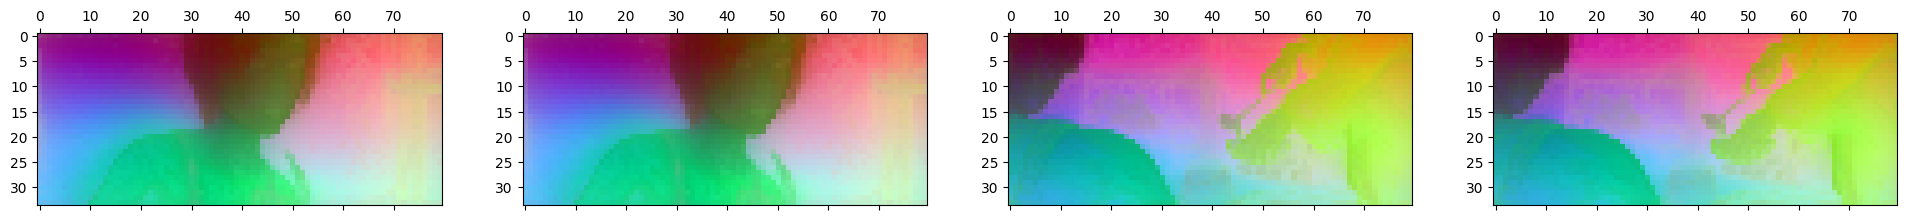

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
for i in range(4):
    ax[i].matshow(pca_array[i])


# Other kinds of output

## Unnormalized features
By default the features are normalized. This can be changed by passing `normalize=False` to the model.

In [17]:
features_unnorm = dinov3(img_tensor_dinov3, normalized=False)
features_unnorm

LocalFeatures(full, unnormalized, shape=(1, 56, 56, 384))

## Frame-level (global) feature vectors

Global features can be produced with the option `features='frame'`. This produces a `torch.Tensor` instead of a `LocalFeatures` object.

In [18]:
global_features = dinov3(img_tensor_dinov3, features='frame')
global_features.shape

torch.Size([1, 384])

## Calculating a deeper PCA and choosing a subset of the components

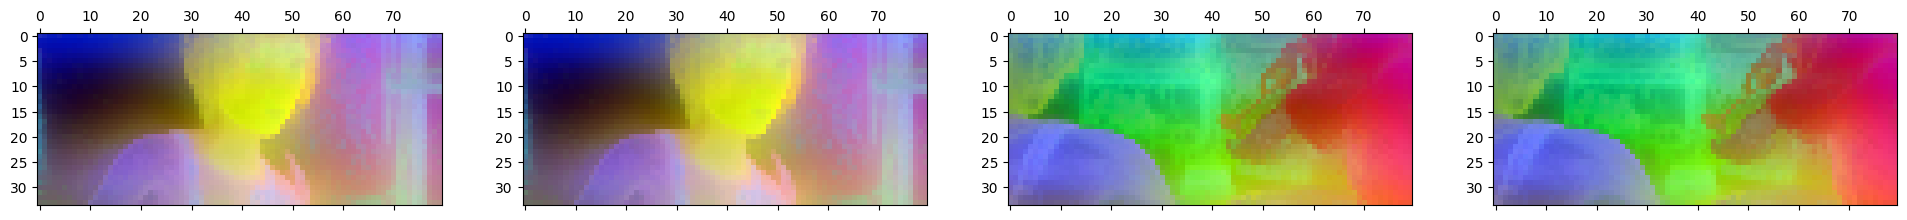

In [19]:
pca_array = dinov3.pca(features, n_components = 16)
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
for i in range(4):
    ax[i].matshow(pca_array[i,:,:,[3,4,5]].transpose(1,2,0))